In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM
from keras.optimizers import Adam

In [58]:
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
models = {
    "LightGBM": LGBMClassifier(random_state=42, is_unbalance=True),
    "CatBoost":CatBoostClassifier(random_seed=42, verbose=0, class_weights=[1, pos_weight]),
    "Logistic": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42)
}

In [60]:
def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(16, input_shape=input_shape))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(0.001), loss='binary_crossentropy')
    return model

In [62]:
optimal_buy_data = {
    "industry": [
        "건설업", "금속제조업", "금융업", "바이오", "반도체제조업", "방송업", "보험업",
        "석유정제", "식료품", "에너지", "자동차", "전자부품", "정보통신업", "조선업", "항공운송"
    ],
    "T_buy": [
        0.1, 0.7, 0.4, 0.5, 0.2, 0.1, 0.2, 0.4, 0.1, 0.4, 0.6, 0.2, 0.1, 0.2, 0.4
    ]
}

In [64]:
manual_weights = {
    '항공운송': {'normalized_score': 0.7, 'score_ma3': 0.1, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3,'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1,'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.7,  'score_change': 0.3}
}

manual_weights = {
    k: list(v.keys()) if isinstance(v, dict) else v
    for k, v in manual_weights.items()
}


In [66]:
df = pd.read_csv('v3_news_2020_2025_06_combined.csv')
df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

In [68]:
def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)

In [76]:
results = []
tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))

for industry, features in manual_weights.items():
    sub = df[df['industry'] == industry].copy().dropna(subset=features)
    t_shift = get_t_shift(industry)
    sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
    sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])

    sub['label'] = (sub['log_return'] > 0.01).astype(int)
    sub = sub.dropna(subset=['label', 'log_return'])

    train = sub[sub['adjusted_date'].dt.year < 2025]
    test = sub[sub['adjusted_date'].dt.year == 2025].copy()

    if train.empty or test.empty:
        continue

    X_train = train[features]
    y_train = train['label']
    X_test = test[features]
    y_test = test['label']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        proba = model.predict_proba(X_test_scaled)[:, 1]
        threshold = tbuy_map.get(industry, 0.5)
        preds = (proba > threshold).astype(int)

        test_temp = test.copy()
        test_temp['strategy_return'] = test_temp['log_return'] * preds
        cum_return = test_temp['strategy_return'].cumsum().iloc[-1] if not test_temp['strategy_return'].isna().all() else np.nan
        results.append({'industry': industry, 'model': model_name, 'cum_return': cum_return})

    # LSTM
    X_train_lstm = np.expand_dims(X_train_scaled, axis=1)
    X_test_lstm = np.expand_dims(X_test_scaled, axis=1)
    lstm = build_lstm((1, X_train_lstm.shape[2]))
    lstm.fit(X_train_lstm, y_train, epochs=10, batch_size=16, verbose=0)
    lstm_proba = lstm.predict(X_test_lstm).flatten()

    threshold = tbuy_map.get(industry, 0.5)
    lstm_preds = (lstm_proba > threshold).astype(int)

    test_temp = test.copy()
    test_temp['strategy_return'] = test_temp['log_return'] * lstm_preds
    cum_return = test_temp['strategy_return'].cumsum().iloc[-1] if not test_temp['strategy_return'].isna().all() else np.nan
    results.append({'industry': industry, 'model': 'LSTM', 'cum_return': cum_return})


[LightGBM] [Info] Number of positive: 230, number of negative: 11606
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000548 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 11836, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019432 -> initscore=-3.921198
[LightGBM] [Info] Start training from score -3.921198
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step
[LightGBM] [Info] Number of positive: 993, number of negative: 33937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 34930, number of

In [77]:
results_df = pd.DataFrame(results)
results_df

,industry,model,cum_return
0,항공운송,LightGBM,0.076544
1,항공운송,CatBoost,-0.003105
2,항공운송,Logistic,0.000000
3,항공운송,RandomForest,0.000000
4,항공운송,LSTM,0.000000
...,...,...,...
70,방송업,LightGBM,0.217674
71,방송업,CatBoost,0.013445
72,방송업,Logistic,0.000000
73,방송업,RandomForest,-0.496805


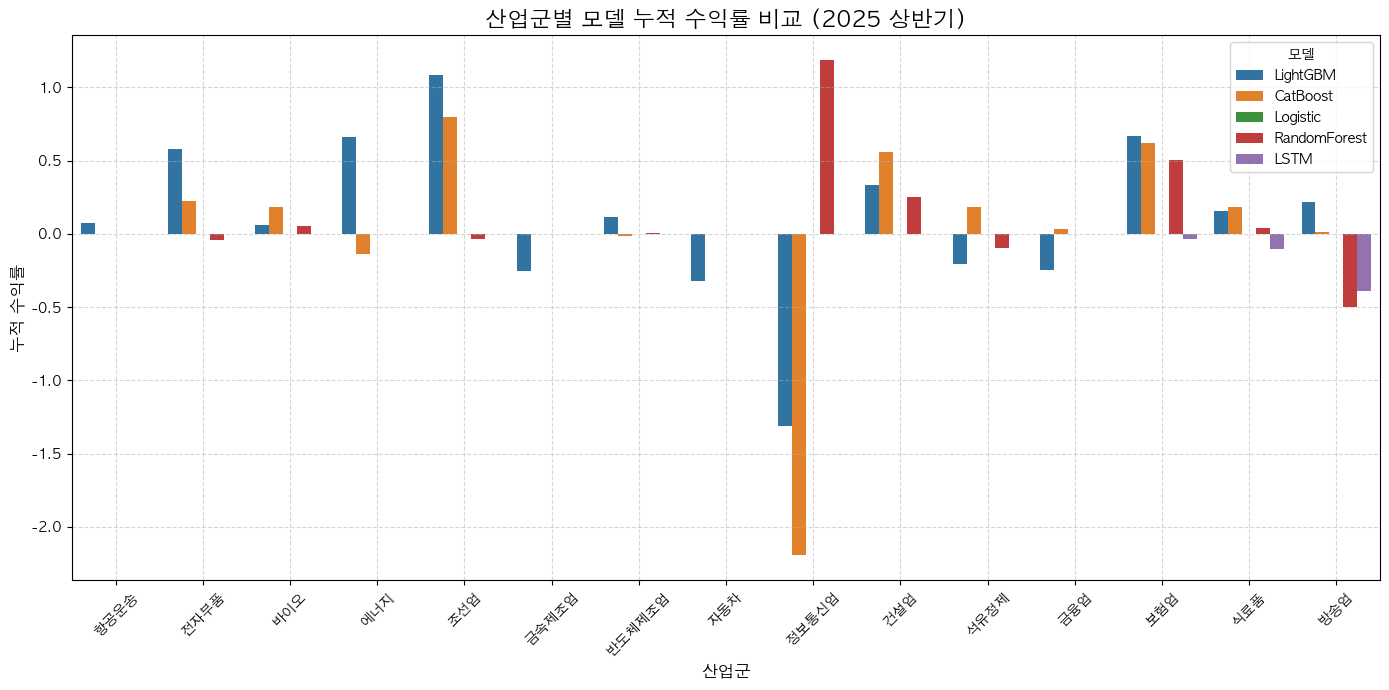

In [78]:
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.barplot(data=results_df, x='industry', y='cum_return', hue='model')

plt.title("산업군별 모델 누적 수익률 비교 (2025 상반기)", fontsize=16)
plt.xlabel("산업군", fontsize=12)
plt.ylabel("누적 수익률", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="모델")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [82]:
df = pd.read_csv("v3_news_2020_2025_06_combined.csv")
df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
df = df.sort_values(by=['industry', 'adjusted_date'])

df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

tbuy_map = dict(zip(optimal_buy_data['industry'], optimal_buy_data['T_buy']))
results = []
model_timeseries = []

for industry, features in manual_weights.items():
    sub = df[df['industry'] == industry].copy().dropna(subset=features)
    t_shift = get_t_shift(industry)
    sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
    sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
    sub['label'] = (sub['log_return'] > 0.01).astype(int)
    sub = sub.dropna(subset=['label', 'log_return'])

    train = sub[sub['adjusted_date'].dt.year < 2025]
    test = sub[sub['adjusted_date'].dt.year == 2025].copy()

    if train.empty or test.empty:
        continue

    X_train = train[features]
    y_train = train['label']
    X_test = test[features]
    y_test = test['label']

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for model_name, model in models.items():
        model.fit(X_train_scaled, y_train)
        proba = model.predict_proba(X_test_scaled)[:, 1]
        threshold = tbuy_map.get(industry, 0.5)
        preds = (proba > threshold).astype(int)

        test_temp = test.copy()
        test_temp['strategy_return'] = test_temp['log_return'] * preds
        test_temp['cum_strategy_return'] = test_temp['strategy_return'].cumsum()
        test_temp['model'] = model_name
        test_temp['industry'] = industry
        model_timeseries.append(test_temp[['adjusted_date', 'industry', 'model', 'cum_strategy_return']])

        final_return = test_temp['cum_strategy_return'].iloc[-1] if not test_temp['cum_strategy_return'].isna().all() else np.nan
        results.append({'industry': industry, 'model': model_name, 'cum_return': final_return})

    # LSTM
    X_train_lstm = np.expand_dims(X_train_scaled, axis=1)
    X_test_lstm = np.expand_dims(X_test_scaled, axis=1)
    lstm = build_lstm((1, X_train_lstm.shape[2]))
    lstm.fit(X_train_lstm, y_train, epochs=10, batch_size=16, verbose=0)
    lstm_proba = lstm.predict(X_test_lstm).flatten()
    threshold = tbuy_map.get(industry, 0.5)
    lstm_preds = (lstm_proba > threshold).astype(int)

    test_temp = test.copy()
    test_temp['strategy_return'] = test_temp['log_return'] * lstm_preds
    test_temp['cum_strategy_return'] = test_temp['strategy_return'].cumsum()
    test_temp['model'] = 'LSTM'
    test_temp['industry'] = industry
    model_timeseries.append(test_temp[['adjusted_date', 'industry', 'model', 'cum_strategy_return']])

    final_return = test_temp['cum_strategy_return'].iloc[-1] if not test_temp['cum_strategy_return'].isna().all() else np.nan
    results.append({'industry': industry, 'model': 'LSTM', 'cum_return': final_return})

[LightGBM] [Info] Number of positive: 230, number of negative: 11606
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000394 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 11836, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.019432 -> initscore=-3.921198
[LightGBM] [Info] Start training from score -3.921198
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step
[LightGBM] [Info] Number of positive: 993, number of negative: 33937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 34930, number of

In [95]:
hold_returns = []
for industry in industries_to_plot:
    temp = timeseries_df[timeseries_df['industry'] == industry].copy()
    if temp.empty: continue
    base = temp.drop_duplicates(subset='adjusted_date').sort_values('adjusted_date')
    base['cum_hold_return'] = base.groupby('industry')['cum_strategy_return'].transform(
        lambda x: x * 0 + base['cum_strategy_return'].diff().fillna(0).cumsum()
    )
    base = base[['adjusted_date', 'industry', 'cum_hold_return']].drop_duplicates()
    hold_returns.append(base)

hold_df = pd.concat(hold_returns, ignore_index=True)

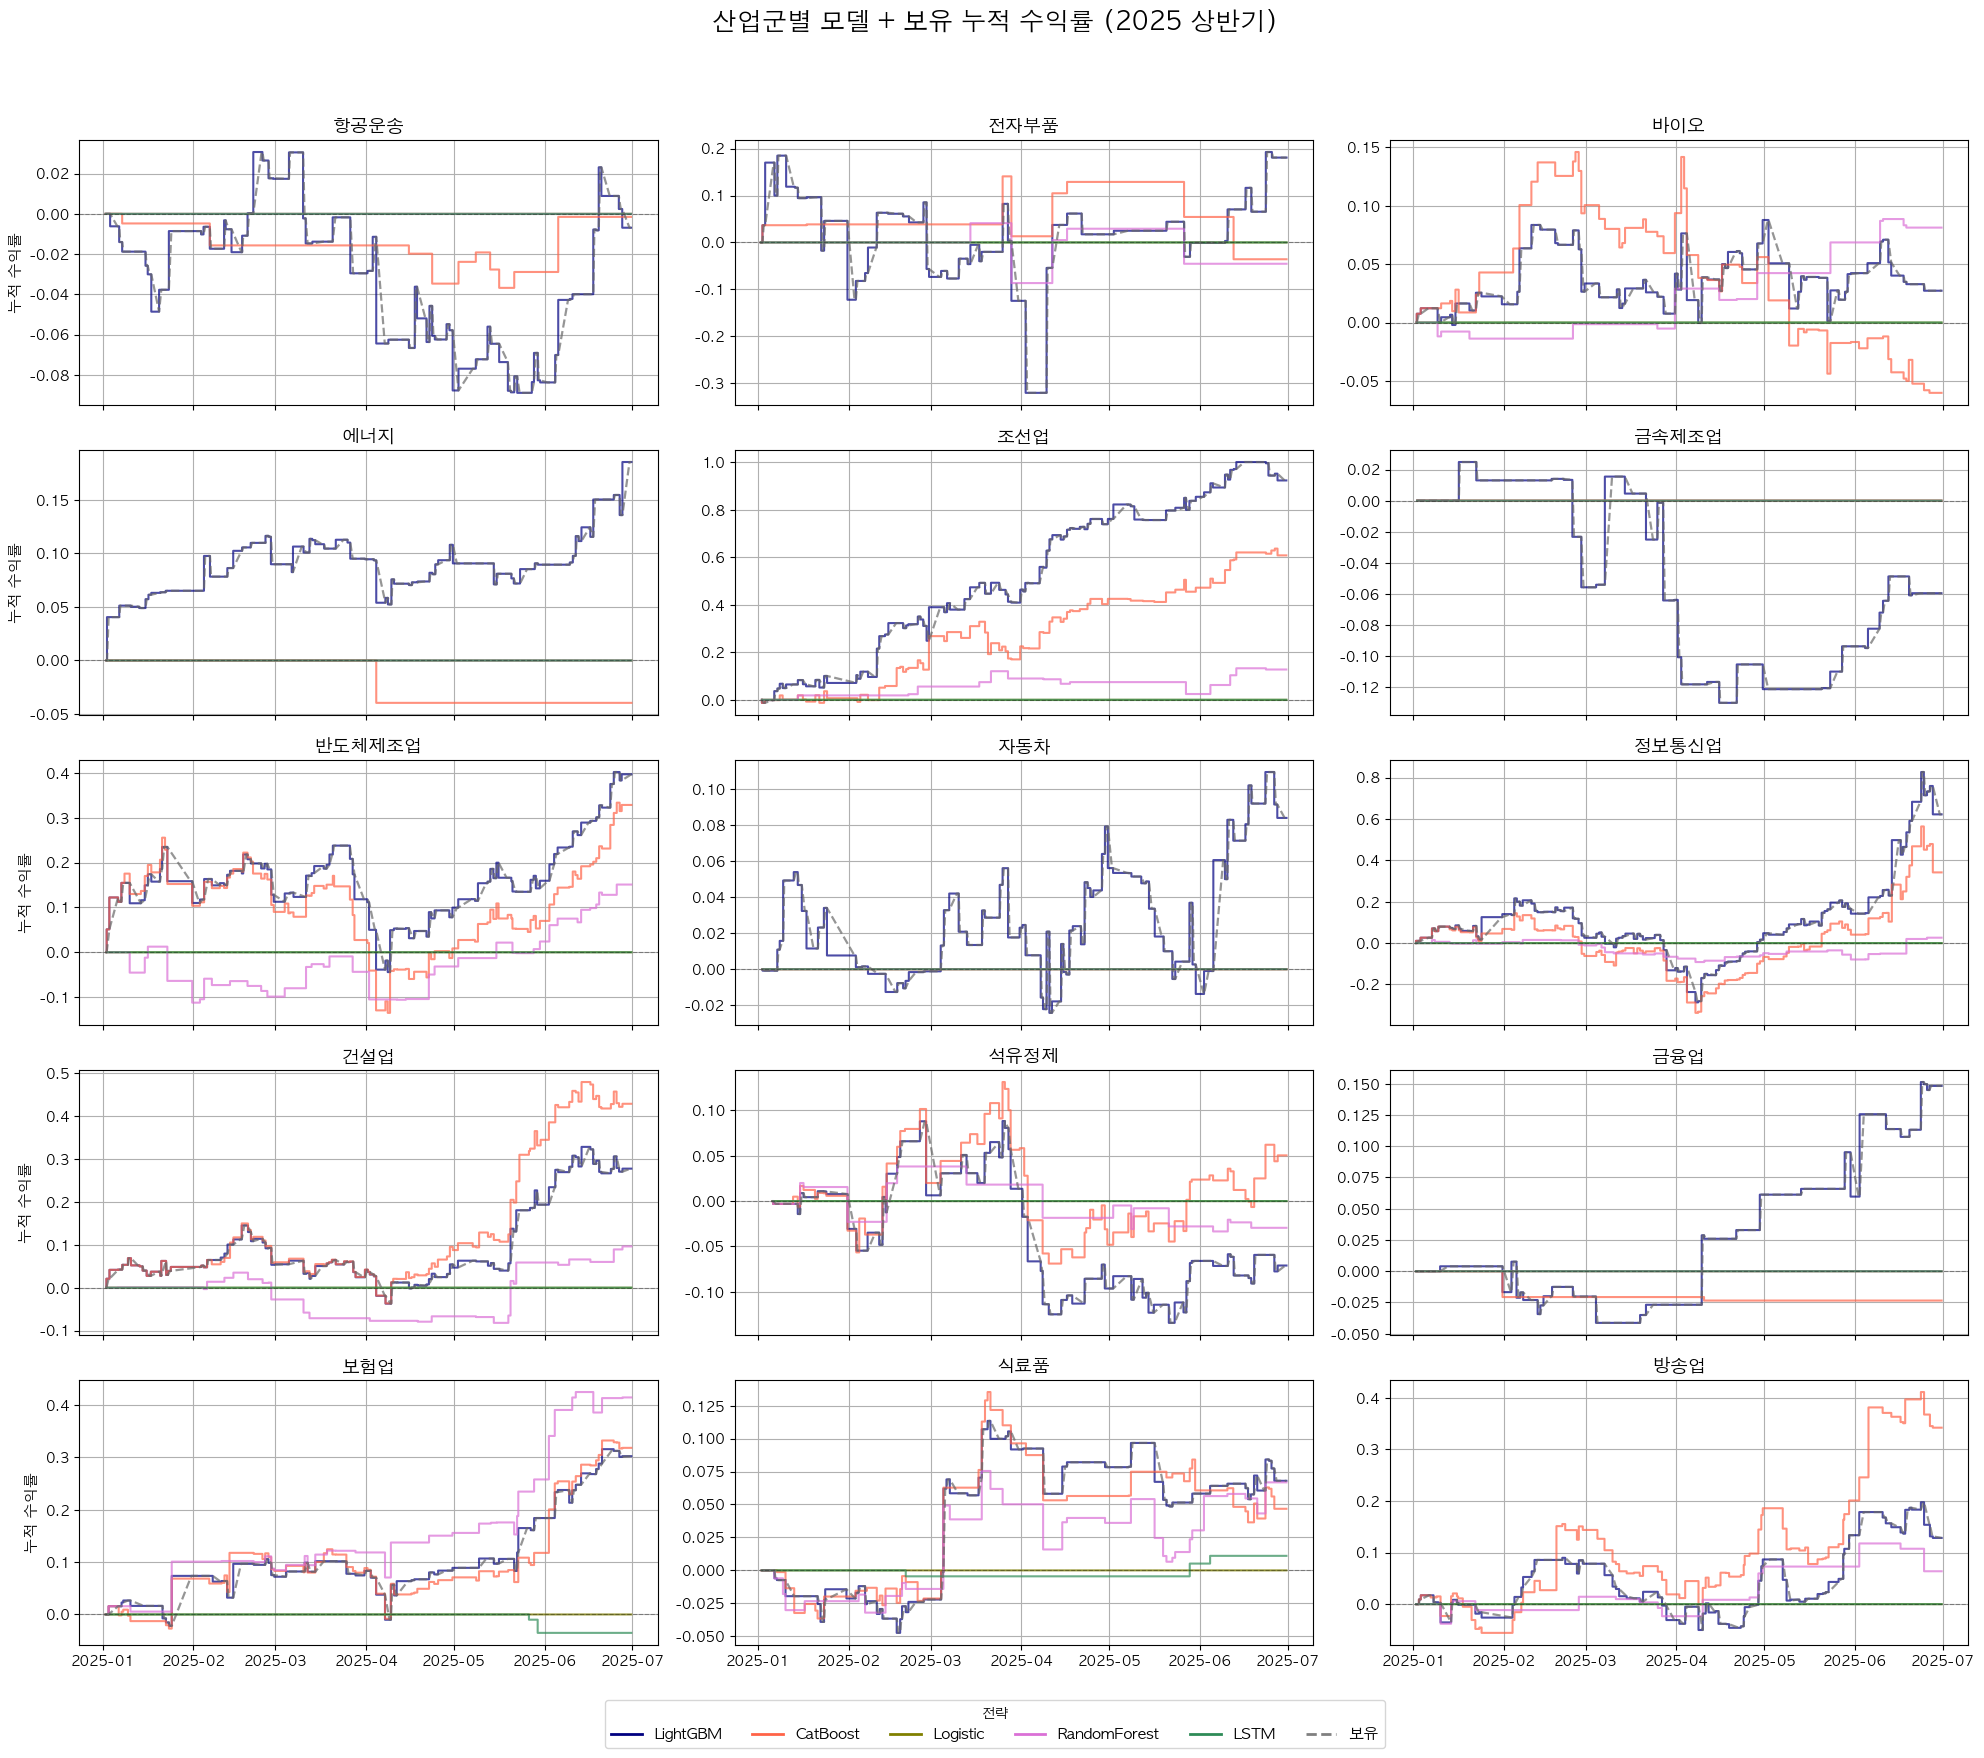

In [105]:
timeseries_df = pd.concat(model_timeseries, ignore_index=True)
industries_to_plot = timeseries_df['industry'].unique()
n_industries = len(industries_to_plot)

n_rows, n_cols = 5, 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18), sharex=True)
axes = axes.flatten()

model_colors = {
    'LightGBM': 'navy',
    'CatBoost': 'tomato',
    'Logistic': 'olive',
    'RandomForest': 'orchid',
    'LSTM': 'seagreen'
}

for i, industry in enumerate(industries_to_plot):
    ax = axes[i]
    sub = timeseries_df[timeseries_df['industry'] == industry]
    hold = hold_df[hold_df['industry'] == industry]

    for model in model_colors.keys():
        model_data = sub[sub['model'] == model]
        if not model_data.empty:
            ax.plot(model_data['adjusted_date'], model_data['cum_strategy_return'],
                    label=model, color=model_colors[model], alpha = 0.7)

    # 보유 전략
    if not hold.empty:
        ax.plot(hold['adjusted_date'], hold['cum_hold_return'],
                label='보유', color='dimgray', linestyle='--', linewidth=1.6, alpha = 0.7)

    ax.set_title(industry, fontsize=13)
    ax.grid(True)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.3)
    ax.tick_params(labelsize=10)
    if i % n_cols == 0:
        ax.set_ylabel("누적 수익률", fontsize=11)

legend_lines = [plt.Line2D([0], [0], color=color, lw=2) for color in model_colors.values()]
legend_labels = list(model_colors.keys()) + ['보유']
legend_lines.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle='--'))

fig.suptitle("산업군별 모델 + 보유 누적 수익률 (2025 상반기)", fontsize=18)
fig.legend(legend_lines, legend_labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=6, fontsize=11, title="전략")
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()